# Análise de Vendas | Deep Ice Cream (DIC)

Dando sequência à Análise Exploratória de Dados (EDA), esta etapa é dedicada à análise do desempenho de vendas, com foco na interpretação dos padrões observados nos dados. São avaliadas as variações de faturamento, volume e ticket médio ao longo do tempo, por categoria de produto e por região, com o objetivo de gerar insights analíticos, sem o uso de modelos preditivos.

## 1. Imports

In [2302]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carregamento dos Dados

In [2304]:
fato = pd.read_csv('dados/dados_vendas.csv')
fato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID_PEDIDO     604 non-null    int64  
 1   DT_PEDIDO     604 non-null    object 
 2   ID_CLIENTE    604 non-null    int64  
 3   ESTADO        604 non-null    object 
 4   ID_PRODUTO    604 non-null    int64  
 5   NM_PRODUTO    604 non-null    object 
 6   ID_CATEG      604 non-null    int64  
 7   QTD           604 non-null    int64  
 8   VL_PRATICADO  604 non-null    float64
 9   TOTAL_ITEM    604 non-null    float64
dtypes: float64(2), int64(5), object(3)
memory usage: 47.3+ KB


In [2305]:
fato['DT_PEDIDO'] = pd.to_datetime(fato['DT_PEDIDO'], format='%Y-%m-%d')

## 3. Hipótese - 1
* Estabilização do faturamento no segundo ano

In [2307]:
# Separando base de 2023 e 2024
df_2023 = fato[fato['DT_PEDIDO'].between('01-01-2023', '31-12-2023')]
df_2024 = fato[fato['DT_PEDIDO'].between('01-01-2024', '31-12-2024')]

In [2308]:
# Criação do Data Frame com o faturamento e volume anual
comparativo = pd.DataFrame({
    'ANO': ['2023', '2024'],
    'FATURAMENTO': [
        df_2023['TOTAL_ITEM'].sum(),
        df_2024['TOTAL_ITEM'].sum()
    ],
    'VOLUME':[
        df_2023['QTD'].sum(),
        df_2024['QTD'].sum()
    ]
})

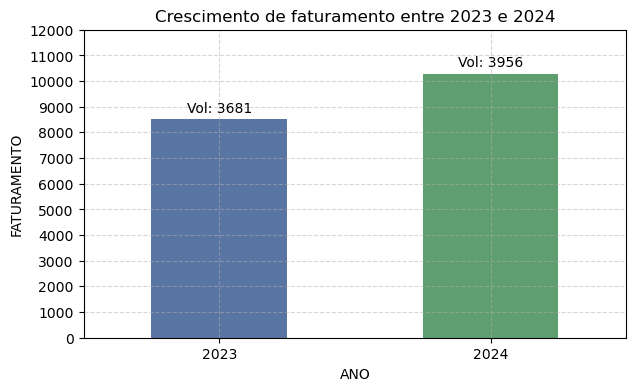

In [2309]:
plt.figure(figsize=(7,4))

ax = sns.barplot(data=comparativo, x='ANO', y='FATURAMENTO', hue='ANO', palette=('#4C72B0', '#55A868'), width=0.5)
for i, v in enumerate(comparativo['VOLUME']):
    ax.text(i, 
            comparativo['FATURAMENTO'].iloc[i]*1.02, 
            f'Vol: {int(v)}',
            ha='center',
            va='bottom')
plt.grid(True, linestyle='--', alpha=0.5)
plt.yticks(range(0,12001,1000))
plt.title('Crescimento de faturamento entre 2023 e 2024')
plt.show()

In [2310]:
# Porcentagem aumento em volume no ano 2024 em comparação com 2023
porcen_vol = ((comparativo['VOLUME'][1] - comparativo['VOLUME'][0]) / comparativo['VOLUME'][0] *100).round(2)
porcen_vol

7.47

Observa-se que, embora o volume vendido tenha aumentado aproximadamente 7.5% em 2024 em relação a 2023, o faturamento apresentou crescimento proporcionalmente superior, indicando possível influência de variações no ticket médio ou no mix de produtos vendidos.

* Avaliando ticket medio

In [2313]:
ticket_2023 = (df_2023['TOTAL_ITEM'].sum()) / (df_2023['ID_PEDIDO'].nunique())
ticket_2024 = (df_2024['TOTAL_ITEM'].sum()) / (df_2024['ID_PEDIDO'].nunique())

df_ticket = pd.DataFrame({
    'ANO': [2023,2024],
    'TICKET_MEDIO': [ticket_2023, ticket_2024]
})

df_ticket['TICKET_MEDIO'] = df_ticket['TICKET_MEDIO'].round()

variacao_ticket = ((ticket_2024 / ticket_2023) - 1) * 100

df_ticket, f'Variação do Ticket médio: {variacao_ticket:.2f}%'

(    ANO  TICKET_MEDIO
 0  2023          36.0
 1  2024          47.0,
 'Variação do Ticket médio: 30.69%')

Observa-se que, embora o volume vendido tenha apresentado crescimento moderado, o ticket médio registrou aumento expressivo de aproximadamente 31%, indicando que o crescimento do faturamento em 2024 foi fortemente influenciado pelo aumento do valor médio por pedido.

* Avaliando variação percentual mês a mês

In [2316]:
temps = (fato.groupby('DT_PEDIDO', as_index=True)
    .agg(
        VOLUME_PEDIDO = ('ID_PEDIDO', 'nunique'),
        TOTAL_MES=('TOTAL_ITEM', 'sum'))
    .sort_index()
)

In [2317]:
# Separando 2023 de 2024
historico_2023 = temps.loc['2023-01-01': '2023-12-31']
df_2023 = (historico_2023.resample('ME')[['VOLUME_PEDIDO', 'TOTAL_MES']].sum())

historico_2024 = temps.loc['2024-01-01': '2024-12-31']
df_2024 = (historico_2024.resample('ME')[['VOLUME_PEDIDO', 'TOTAL_MES']].sum())


In [2318]:
# Criando coluna de apoio Mês
df_2023['MES'] = [int(x+1) for x in range(len(df_2023))]
df_2024['MES'] = [int(x+1) for x in range(len(df_2024))]

In [2319]:
# Criando Coluna de variação mês a mês (MoM%)
mom_2023 = df_2023.copy()
mom_2024 = df_2024.copy()

mom_2023['MoM_2023'] = (mom_2023['TOTAL_MES'].pct_change()*100).round()
mom_2024['MoM_2024'] = (mom_2024['TOTAL_MES'].pct_change()*100).round()

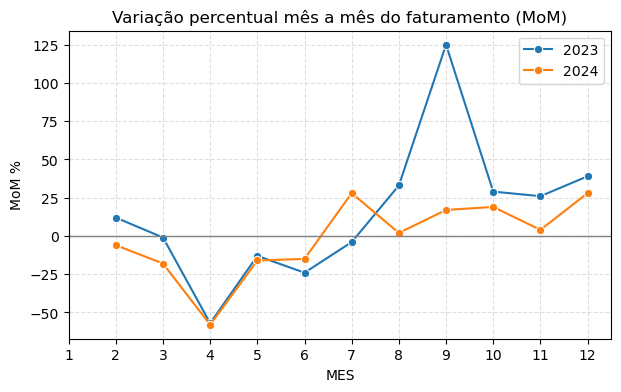

In [2320]:
plt.figure(figsize=(7,4))

sns.lineplot(data=mom_2023, x='MES', y='MoM_2023', marker='o', label='2023')
sns.lineplot(data=mom_2024, x='MES', y='MoM_2024', marker='o', label='2024') 
plt.axhline(0, color='gray', linewidth=1)
plt.xticks(range(1,13))
plt.ylabel('MoM %')
plt.title('Variação percentual mês a mês do faturamento (MoM)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

O cálculo da variação mês a mês (MoM) foi realizado separadamente para cada ano, de modo a evitar a influência de valores do ano anterior na análise comparativa entre períodos.

Observa-se que alguns meses apresentam variações percentuais elevadas, especialmente quando há mudanças abruptas no volume de vendas.    
Isso ocorre porque, em bases com valores menores, pequenas variações absolutas podem resultar em grandes variações percentuais.

In [2323]:
desvio_2023 = mom_2023['MoM_2023'].std()
desvio_2024 = mom_2024['MoM_2024'].std()

desvio = pd.DataFrame({
    'ANO': [2023, 2024],
    'STD': [round(desvio_2023,2), round(desvio_2024,2)]
})
desvio

,ANO,STD
0,2023,46.29
1,2024,25.34


O desvio padrão das variações mensais (MoM) em 2023 foi de 46,29, enquanto em 2024 foi de 25,34.
Esse resultado indica que o primeiro ano apresentou maior volatilidade nas vendas mensais, enquanto o segundo ano apresentou variações mais moderadas, sugerindo um padrão de faturamento mais estável.

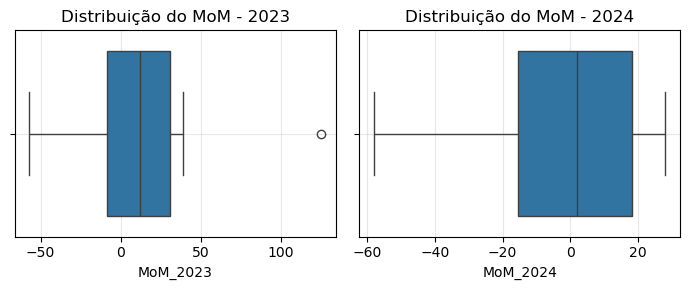

In [2325]:
fig, axes = plt.subplots(1,2,figsize=(7,3))

sns.boxplot(data=mom_2023, x='MoM_2023', ax=axes[0])
axes[0].set_title('Distribuição do MoM - 2023')

sns.boxplot(data=mom_2024, x='MoM_2024', ax=axes[1])
axes[1].set_title('Distribuição do MoM - 2024')

plt.tight_layout()
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
plt.show()

A análise das variações mensais (MoM) mostra que o primeiro ano apresenta oscilações significativamente maiores no faturamento. O desvio padrão das variações em 2023 foi de 46.29, enquanto em 2024 foi de 25.34, indicando menor volatilidade no segundo ano.

O boxplot também mostra maior dispersão das variações em 2023, com presença de valores extremos, enquanto 2024 apresenta distribuição mais concentrada. Esses resultados sugerem que o faturamento apresentou maior estabilidade no segundo ano de operação.

A redução da volatilidade das variações mensais em 2024 sugere um comportamento mais estável do faturamento ao longo do ano. Esse padrão é acompanhado por um aumento no ticket médio, cerca de 31% maior que em 2023, indicando que o crescimento das vendas ocorreu de forma mais consistente e sustentável.

Em conjunto, os resultados indicam que o segundo ano apresenta não apenas maior estabilidade nas vendas, mas também um crescimento sustentado pelo aumento do ticket médio.

## 4. Hipótese - 2
* Possível sazonalidade nas vendas

In [2330]:
sazonal = pd.concat([df_2023, df_2024], ignore_index=True)
sazonal = (sazonal.groupby('MES')
           .agg(
               MEDIA_MES = ('TOTAL_MES', 'mean')
           )
          )

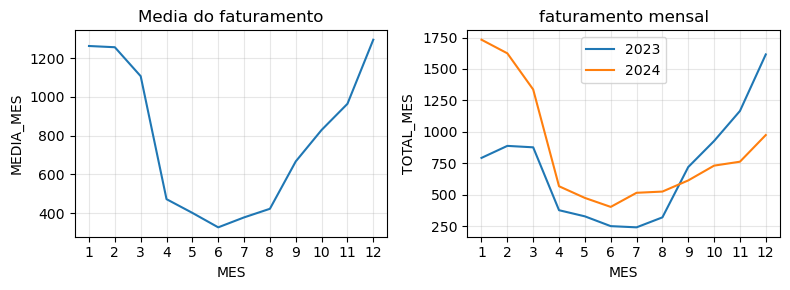

In [2331]:
fig, axes = plt.subplots(1,2, figsize=(8,3))


sns.lineplot(data=sazonal, x=sazonal.index, y='MEDIA_MES', ax=axes[0])
axes[0].set_title('Media do faturamento')
axes[0].set_xticks(range(1,13))
axes[0].grid(alpha=0.3)

sns.lineplot(data=df_2023, x='MES', y='TOTAL_MES', label = '2023',ax=axes[1])
sns.lineplot(data=df_2024, x='MES', y='TOTAL_MES', label = '2024',ax=axes[1])
axes[1].legend(loc='upper center')
axes[1].set_title('faturamento mensal')
axes[1].set_xticks(range(1,13))
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

A análise do faturamento médio por mês indica um padrão consistente ao longo do ano, com maiores valores no início e no final do período e uma redução no meio do ano.

Esse comportamento também aparece na comparação entre 2023 e 2024, já que ambos os anos apresentam uma dinâmica semelhante ao longo dos meses.

Esses resultados sugerem a presença de um padrão sazonal nas vendas, ainda que a análise esteja limitada a dois anos de dados.

## 5. Hipótese - 3
* Concentração de receita em poucos produtos

In [2334]:
# Criando agrupamento dos produtos e seus faturamentos
faturamento_produto = (fato.groupby('NM_PRODUTO')
                     .agg(
                         QTD_PEDIDO = ('ID_PEDIDO', 'nunique'),
                         FATURAMENTO = ('TOTAL_ITEM', 'sum')
                     ).sort_values('FATURAMENTO', ascending=False)
                     )

In [2335]:
# Adiquirindo a participação em porcentagem de cada produto
faturamento_total = fato['TOTAL_ITEM'].sum()
porcentagem = round((faturamento_produto['FATURAMENTO'] / faturamento_total ) *100, 1)
participacao = porcentagem.to_frame(name='PARTICIPACAO')

In [2336]:
# Top 2 produtos com maior receita
top2 = faturamento_produto.head(2).copy()

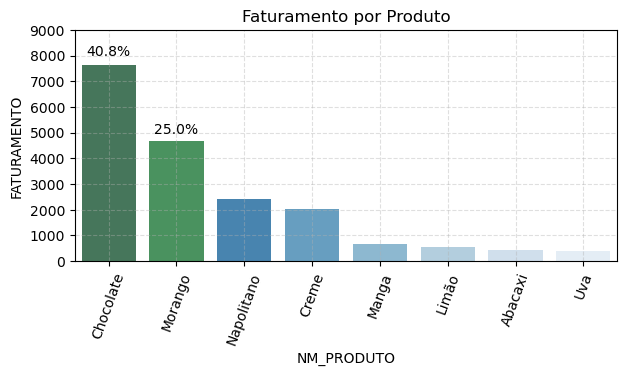

In [2337]:
plt.figure(figsize=(7,3))

sns.barplot(data=faturamento_produto, x='NM_PRODUTO', y='FATURAMENTO', hue='NM_PRODUTO', palette='Blues_r')

ax = sns.barplot(data=top2, x='NM_PRODUTO', y='FATURAMENTO', hue='NM_PRODUTO', palette=('#3E7E5A','#3E9E5A'))
for i, v in enumerate(participacao['PARTICIPACAO']):
    if i < 2:
        ax.text(i,
                faturamento_produto['FATURAMENTO'].iloc[i] * 1.03,
                f'{float(v):.1f}%',
                ha='center',
                va='bottom')

plt.xticks(rotation=70)
plt.title('Faturamento por Produto')
plt.grid(True, linestyle='--', alpha=0.4)
plt.yticks(range(0,9001,1000))

plt.show()

Observa-se que os dois principais produtos concentram aproximadamente 65% do faturamento total, indicando uma forte dependência de um pequeno grupo de itens. Esse comportamento sugere uma distribuição assimétrica da receita, alinhada ao princípio de Pareto, onde poucos produtos são responsáveis pela maior parte dos resultados.

## 6. Hipótese - 4
* O ticket médio pode variar significativamente entre os produtos

In [2340]:
ticket = (fato.groupby('NM_PRODUTO')
               .agg(
                   VOLUME_PEDIDO = ('ID_PEDIDO', 'nunique'),
                   FATURAMENTO = ('TOTAL_ITEM', 'sum')
               ).sort_values('FATURAMENTO', ascending=False)
               )
ticket['TICKET_MEDIO'] = (ticket['FATURAMENTO'] / ticket['VOLUME_PEDIDO']).round(2)

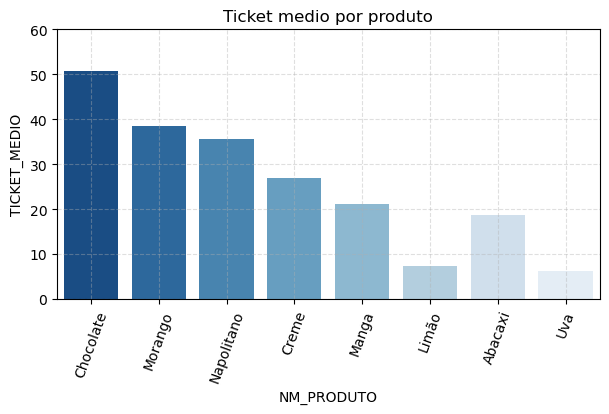

In [2341]:
plt.figure(figsize=(7,3.5))

sns.barplot(data=ticket, x='NM_PRODUTO', y='TICKET_MEDIO', hue='NM_PRODUTO', palette='Blues_r')
plt.title('Ticket medio por produto')
plt.xticks(rotation=70)
plt.grid(True, linestyle='--', alpha=0.4)
plt.yticks(range(0,61,10))

plt.show()

Observa-se que os produtos com maior ticket médio tendem a concentrar também os maiores níveis de faturamento, indicando uma relação positiva  
entre   essas variáveis.   
No entanto, os produtos com menor desempenho não apresentam um padrão claro, sugerindo que, nesse grupo, o faturamento não é explicado apenas  
pelo ticket médio.

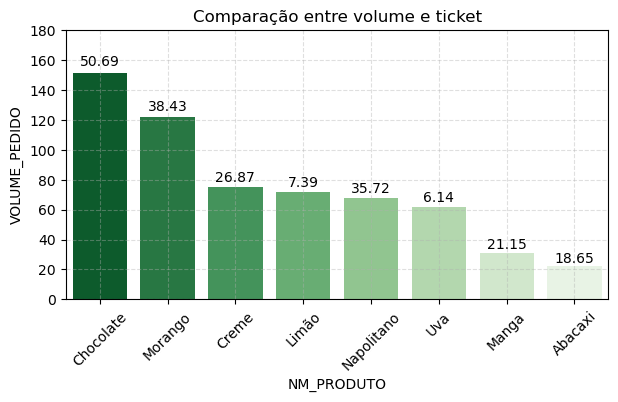

In [2343]:
ticket = ticket.sort_values('VOLUME_PEDIDO', ascending=False)

plt.figure(figsize=(7,3.5))

ax = sns.barplot(data=ticket, x='NM_PRODUTO', y='VOLUME_PEDIDO', hue='NM_PRODUTO', palette='Greens_r')
for i, v in enumerate(ticket['TICKET_MEDIO']):
    ax.text(i,
            ticket['VOLUME_PEDIDO'].iloc[i]*1.02,
            f'{v}',
            ha='center',
            va='bottom'
    )
plt.xticks(rotation=45)
plt.title('Comparação entre volume e ticket')
plt.yticks(range(0,181, 20))
plt.grid(linestyle='--', alpha=0.4)

plt.show()

Isso sugere que produtos como Limão e Uva apresentam volumes de pedidos relativamente altos, porém com tickets médios inferiores aos demais. Esse comportamento indica que a relação entre volume e ticket médio não é direta, reforçando que produtos podem gerar receita tanto pela frequência de vendas quanto pelo valor agregado por transação.  
Dessa forma, a hipótese de que os produtos apresentam diferenças significativas de ticket médio é confirmada, embora essa métrica não esteja diretamente associada ao volume de vendas.

## 7. Hipótese - 5
* A distribuição de vendas pode variar muito entre as regiões.

In [2378]:
participacao_estado = (fato.groupby('ESTADO')
                     .agg(
                         VOLUME_PEDIDO = ('ID_PEDIDO', 'nunique'),
                         FATURAMENTO = ('TOTAL_ITEM', 'sum')
                     ).sort_values('FATURAMENTO', ascending=False)
                     )
participacao_estado['PARTICIPACAO'] = ((participacao_estado['FATURAMENTO']/ participacao_estado['FATURAMENTO'].sum()) * 100).round(1)

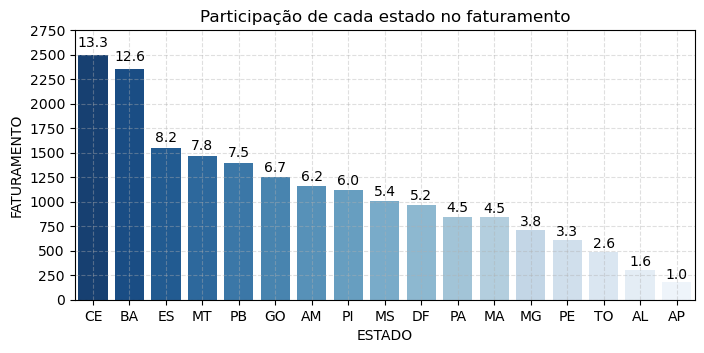

In [2396]:
plt.figure(figsize=(8,3.5))

ax = sns.barplot(data=participacao_estado, x='ESTADO', y='FATURAMENTO', hue='ESTADO', palette='Blues_r')
for i, v in enumerate(participacao_estado['PARTICIPACAO']):
    ax.text(i,
            participacao_estado['FATURAMENTO'].iloc[i]*1.02,
            f'{v}',
            ha='center',
            va='bottom'        
    )
plt.title('Participação de cada estado no faturamento')
plt.grid(linestyle='--', alpha=0.4)
plt.yticks(range(0, 2751, 250))

plt.show()

Isso indica que o faturamento está concentrado principalmente nos estados do Ceará (CE) e Bahia (BA), que apresentam as maiores participações.  
Os demais estados possuem contribuições mais distribuídas, com queda gradual ao longo do ranking.

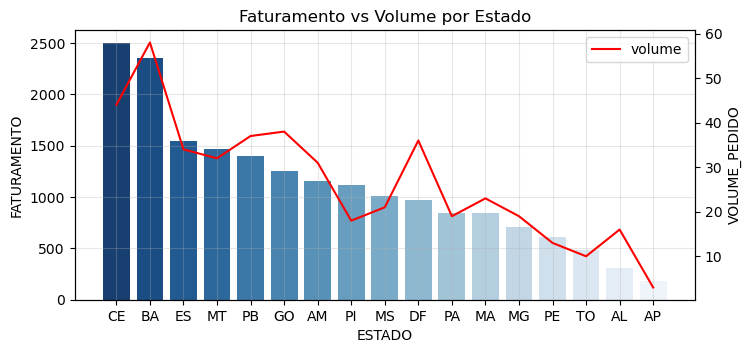

In [2476]:
plt.figure(figsize=(8,3.5))

ax = sns.barplot(data=participacao_estado, x='ESTADO', y='FATURAMENTO', hue='ESTADO', palette='Blues_r')

ax2 = ax.twinx()
sns.lineplot(data=participacao_estado, x= 'ESTADO', y='VOLUME_PEDIDO', color='red', label='volume', ax=ax2)


plt.title('Faturamento vs Volume por Estado')
ax.grid(alpha=0.3)

plt.show()

A análise conjunta de faturamento e volume de pedidos indica que estados como Ceará (CE) e Bahia (BA) concentram tanto alto volume quanto elevada geração de receita. Contudo, essa relação não se mantém de forma consistente ao longo dos demais estados, sugerindo que o faturamento pode ser influenciado tanto pela quantidade de pedidos quanto pelo valor médio por transação.

## Conclusão

A análise realizada evidencia que o faturamento é influenciado por uma combinação de fatores, principalmente o volume de vendas e o ticket médio. Observou-se que os produtos e estados com maior desempenho, como Chocolate no nível de produto e Ceará (CE) e Bahia (BA) no nível regional, apresentam simultaneamente altos volumes de pedidos e maior valor por transação.

No entanto, essa relação não é uniforme em todos os casos, sendo possível identificar produtos e estados que apresentam bom desempenho em apenas uma dessas dimensões, seja por alta frequência de vendas ou por maior valor agregado.

Além disso, foi possível observar uma concentração de faturamento em determinados produtos e regiões, indicando a relevância estratégica desses elementos para a geração de receita.

Dessa forma, conclui-se que uma análise isolada de volume ou ticket médio não é suficiente para explicar o desempenho, sendo fundamental considerar essas métricas de forma integrada para uma melhor compreensão do negócio e suporte à tomada de decisão.